## Test Mass Assignment Scheme

This notebook compares the implementation of the mass assignment scheme with Pylians

In [1]:
import MAS_library as MASL
import readfof
import matplotlib.pyplot as plt
import numpy as np


# Re-linking the removed nomenclature to the current functional equivalents
if not hasattr(np, 'product'):
    np.product = np.prod
    np.asfarray = np.asarray

import pmesh as pm

In [2]:
import Pk_library as PKL

In [3]:
import sys
import os
import glob as glob

notebook_dir = os.getcwd()
# Get the directory of the current notebook
print(notebook_dir  # usually the folder where notebook resides
)

/mnt/project_mnt/home_fs/emaragliano/Work/Projects/Dottorato/ZeldovichReconstruction/tests


In [4]:
repo_path = '/home/emaragliano/Work/Projects/Dottorato/ZeldovichReconstruction'
sys.path.insert(0, repo_path)

In [5]:
sys.path

['/home/emaragliano/Work/Projects/Dottorato/ZeldovichReconstruction',
 '/mnt/project_mnt/home_fs/emaragliano/Work/Projects/Dottorato/ZeldovichReconstruction/tests',
 '/home/emaragliano/Pylians/library/build/lib.linux-x86_64-2.7',
 '/conda/conda/emaragliano/envs/BAOrec/lib/python310.zip',
 '/conda/conda/emaragliano/envs/BAOrec/lib/python3.10',
 '/conda/conda/emaragliano/envs/BAOrec/lib/python3.10/lib-dynload',
 '',
 '/home/emaragliano/.local/lib/python3.10/site-packages',
 '/mnt/project_mnt/farm_fs/emaragliano/TR1_reconstruction_code/tr1_reconstruction',
 '/mnt/project_mnt/farm_fs/emaragliano/TR1_reconstruction_code/za_recon_tools',
 '/conda/conda/emaragliano/envs/BAOrec/lib/python3.10/site-packages']

In [6]:
import zeldareco as zr

print(zr.__file__)

/conda/conda/emaragliano/envs/BAOrec/lib/python3.10/site-packages/numba/core/decorators.py:248: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


/home/emaragliano/Work/Projects/Dottorato/ZeldovichReconstruction/zeldareco/__init__.py


In [7]:
import zeldareco.mass_assignment as ma

In [8]:
ma._mass_assignment_info()

2026-05-13 12:59:36,383 - zeldareco.mass_assignment - INFO - 
    Mass Assignment Schemes implemented:
    - NGP (Nearest Grid Point)
    - CIC (Cloud-In-Cell)
    - TSC (Triangular Shaped Cloud)

    Each method has its own function for mass assignment from particles to grid.
    The main wrapper function 'mass_assignment' allows selection of the method.

    Additionally, grid-to-particle interpolation functions are provided for each scheme.
    


In [9]:
#sys.path.append(os.path.relpath('../../../../AstroCosmoComputational/Students/MaraglianoEdo/pyACC'))

In [10]:
path_quijote = '/farmdisk1/ganeshai/Quijote/QUIJOTE_FROM_BINDER/Halos/FoF/fiducial_HR/0'
snapnum = 2
z_dict = {4: 0.0, 3: 0.5, 2: 1.0, 1: 2.0, 0: 3.0}
redshift = z_dict[snapnum]

In [11]:
FoF = readfof.FoF_catalog(path_quijote, snapnum, long_ids=False, swap=False, SFR=False, read_IDs=False)

In [12]:
# Get halo properties
pos_h = FoF.GroupPos / 1e3            # Positions in Mpc/h
mass = FoF.GroupMass * 1e10           # Masses in Msun/h
vel_h = FoF.GroupVel * (1.0 + redshift)  # Peculiar velocities in km/s
Npart = FoF.GroupLen                  # Number of particles in the halo

In [13]:
mass = None

In [14]:
# density field parameters
nmesh = 1024
grid    = nmesh    #the 3D field will have grid x grid x grid voxels
BoxSize = 1000.0 #Mpc/h ; size of box
MAS     = 'CIC'  #mass-assigment scheme
verbose = True   #print information on progress

In [15]:
len(pos_h)

2382393

# Test CIC

## Pylians

In [16]:
# define 3D density field
cic_rho_pylians = np.zeros((grid,grid,grid), dtype=np.float32)

# construct 3D density field
MASL.MA(pos_h, cic_rho_pylians, BoxSize, MAS, W=mass, verbose=verbose)

# at this point, cic_delta_pylians contains the effective number of particles in each voxel
# now compute overdensity and density constrast
cic_delta_pylians = cic_rho_pylians / np.mean(cic_rho_pylians, dtype=np.float32) - 1.0


Using CIC mass assignment scheme
Time taken = 2.248 seconds



In [17]:
kmin = kfund = 2.0 * np.pi / BoxSize
kmax = knyq = np.pi / BoxSize * grid

## CIC zeldareco

In [18]:
grid_shape = (nmesh, nmesh, nmesh)

In [19]:
from numba import njit, prange, set_num_threads, get_num_threads

set_num_threads(32)

In [20]:
get_num_threads()

32

In [21]:
cic_rho_new = ma.cic_ma(pos_h, BoxSize, nmesh, mass, pbc=True, dtype=np.float64, verbose=True, parallel=False)

2026-05-13 12:59:40,066 - zeldareco.mass_assignment - INFO - Starting CIC mass assignment...
2026-05-13 12:59:40,070 - zeldareco.mass_assignment - INFO - weights not provided. Assuming all particles have unit weight.
2026-05-13 12:59:42,136 - zeldareco.mass_assignment - INFO - Using single-threaded CIC interpolation.

2026-05-13 12:59:42,137 - zeldareco.mass_assignment - INFO - CIC mass assignment completed in 2.071151 seconds.


In [22]:
cic_delta_new = cic_rho_new / np.mean(cic_rho_new, dtype=np.float64) - 1.0

## pmesh

In [23]:
from pmesh.pm import ParticleMesh, RealField


In [24]:
mesh = ParticleMesh(BoxSize=BoxSize, Nmesh=grid_shape, resampler='cic')
pyrecon_rho_cic = mesh.paint(pos_h, resampler='cic')
type(pyrecon_rho_cic.value)
cic_delta_pyrecon = pyrecon_rho_cic.value / pyrecon_rho_cic.value.mean() - 1.0

### compare

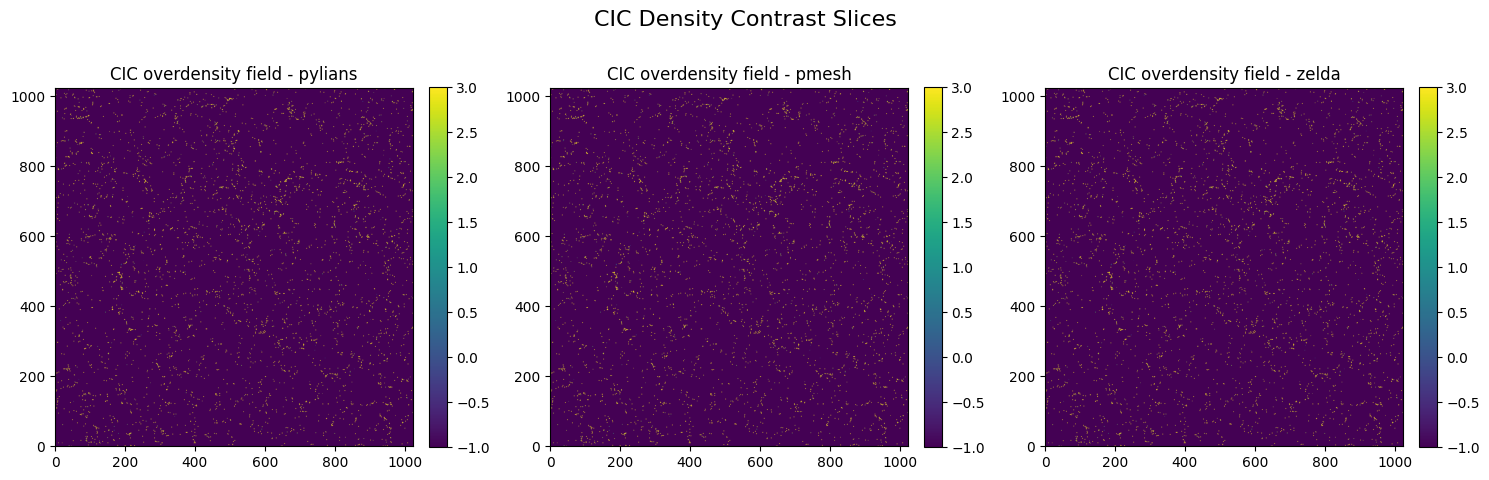

In [25]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
slab = 40
im0 = axs[0].imshow(cic_delta_pylians[:, :, slab],
                     vmin=-1, vmax=3, origin='lower', cmap='viridis')
axs[0].set_title('CIC overdensity field - pylians')
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)  

im1 = axs[1].imshow(cic_delta_pyrecon[:, :, slab],
                     vmin=-1, vmax=3, origin='lower', cmap='viridis')
axs[1].set_title('CIC overdensity field - pmesh')
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

im2 = axs[2].imshow(cic_delta_new[:, :, slab],
                     vmin=-1, vmax=3, origin='lower', cmap='viridis')
axs[2].set_title('CIC overdensity field - zelda')
fig.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)
plt.suptitle('CIC Density Contrast Slices', fontsize=16)
plt.tight_layout()
plt.show()

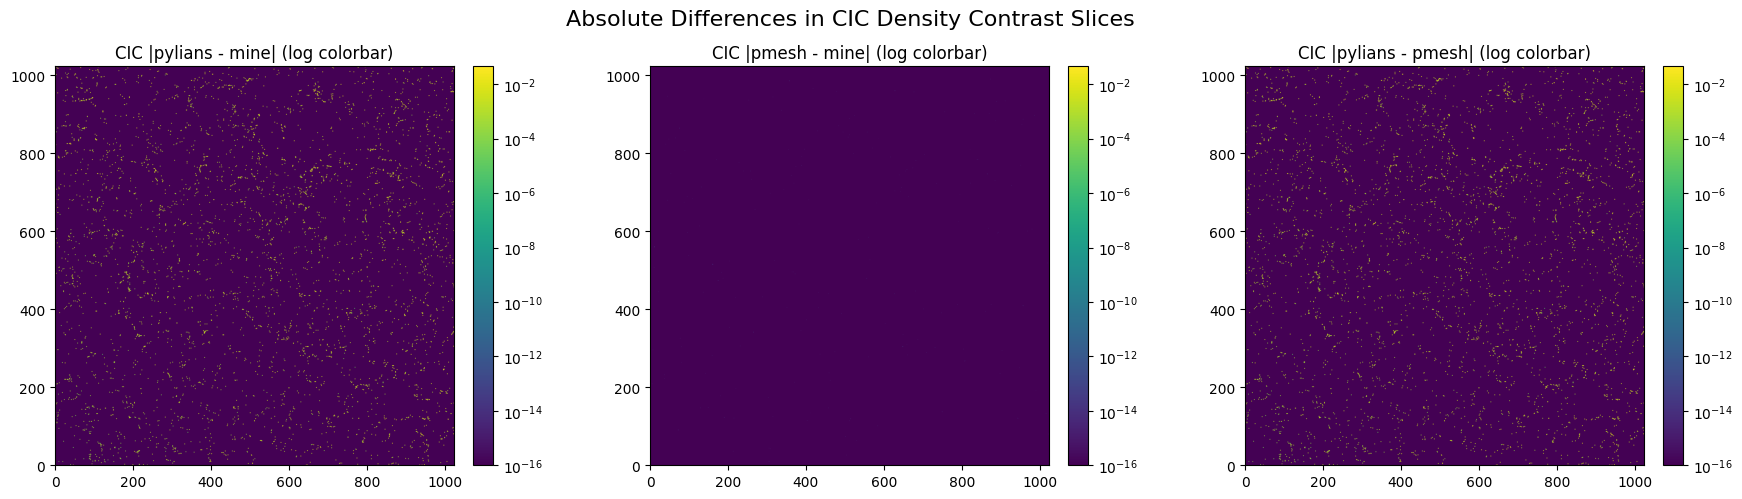

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

slab = 40
from matplotlib.colors import LogNorm

# use absolute differences (log scale needs positive values) and add small epsilon
eps = 1e-16
diff0 = np.abs(cic_delta_pylians[:, :, slab] - cic_delta_new[:, :, slab]) + eps
diff1 = np.abs(cic_delta_pyrecon[:, :, slab] - cic_delta_new[:, :, slab]) + eps
diff3 = np.abs(cic_delta_pylians[:, :, slab] - cic_delta_pyrecon[:, :, slab]) + eps

# set common vmin/vmax for comparable colorbars, ensure vmin>0 for LogNorm
vmin = max(eps, min(diff0.min(), diff1.min(), diff3.min()))
vmax = max(diff0.max(), diff1.max(), diff3.max(),)
norm = LogNorm(vmin=vmin, vmax=vmax)

im0 = axes[0].imshow(diff0, norm=norm, origin='lower', cmap='viridis')
axes[0].set_title('CIC |pylians - mine| (log colorbar)')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(diff1, norm=norm, origin='lower', cmap='viridis')
axes[1].set_title('CIC |pmesh - mine| (log colorbar)')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(diff3, norm=norm, origin='lower', cmap='viridis')
axes[2].set_title('CIC |pylians - pmesh| (log colorbar)')
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle('Absolute Differences in CIC Density Contrast Slices', fontsize=16)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1553948/2327974938.py:6: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(-1, 3)


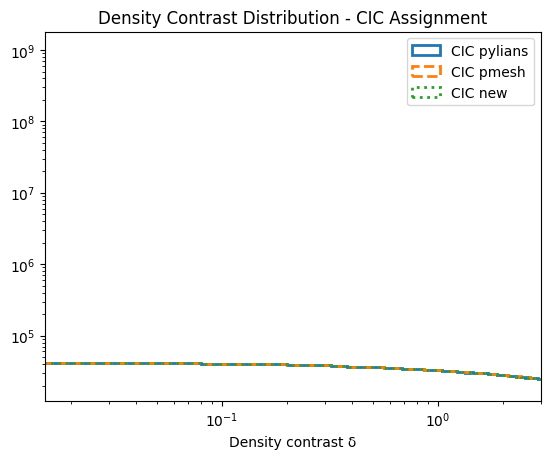

In [27]:
plt.hist(cic_delta_pylians.flatten(), range=(-1, 5), bins=100, alpha=1, label='CIC pylians', histtype='step', linewidth=2)
plt.hist(cic_delta_pyrecon.flatten(), range=(-1, 5), bins=100, alpha=1, label='CIC pmesh', histtype='step', linestyle='dashed', linewidth=2)
plt.hist(cic_delta_new.flatten(), range=(-1, 5), bins=100, alpha=1, label='CIC new', histtype='step', linestyle='dotted', linewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.xlim(-1, 3)
plt.xlabel('Density contrast δ')
plt.title('Density Contrast Distribution - CIC Assignment')
plt.legend()

In [28]:
pk_pylians = PKL.Pk(cic_delta_pylians, BoxSize, axis=0, MAS=MAS, threads=1)
pk_cic_pyrecon = PKL.Pk(cic_delta_pyrecon.astype(np.float32), BoxSize, axis=0, MAS=MAS, threads=1)
pk_cic_new = PKL.Pk(cic_delta_new.astype(np.float32), BoxSize, axis=0, MAS=MAS, threads=1)


Computing power spectrum of the field...
Time to complete loop = 36.12
Time taken = 60.03 seconds

Computing power spectrum of the field...
Time to complete loop = 36.99
Time taken = 76.12 seconds

Computing power spectrum of the field...
Time to complete loop = 36.94
Time taken = 71.48 seconds


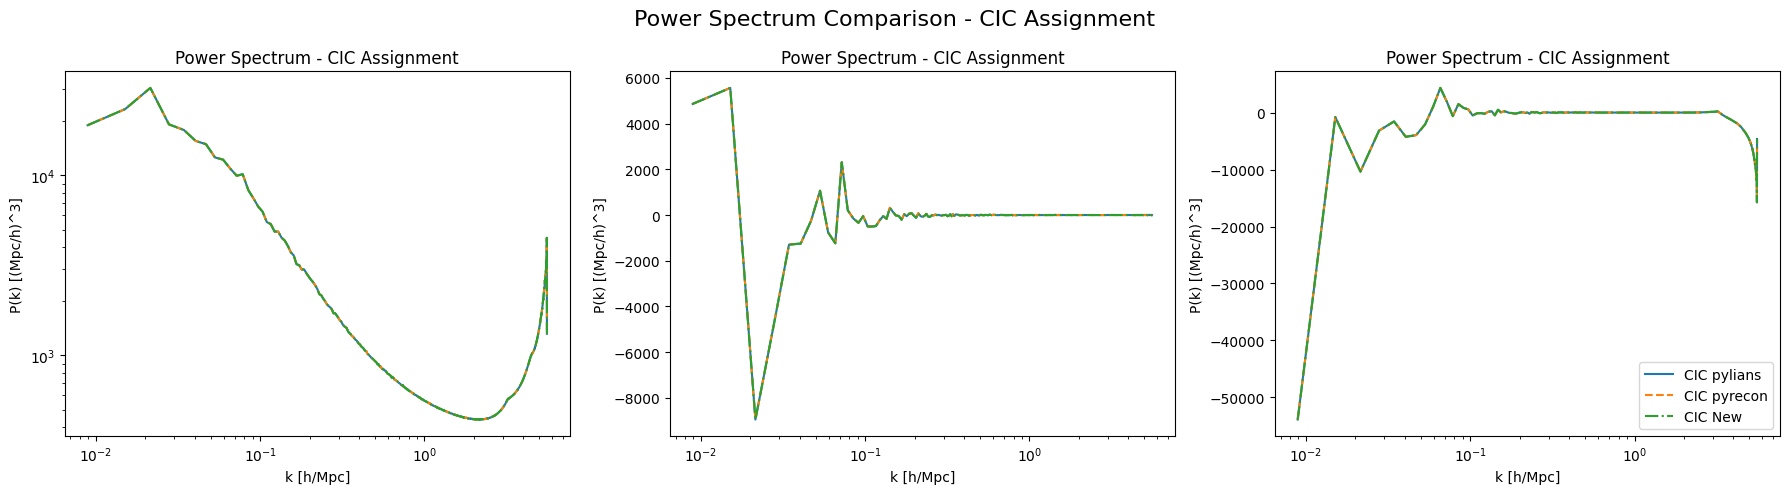

In [29]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
for i, ax in enumerate(axs):

    ax.plot(pk_pylians.k3D, pk_pylians.Pk[:,i], label='CIC pylians', linestyle='solid')
    ax.plot(pk_cic_pyrecon.k3D, pk_cic_pyrecon.Pk[:,i], label='CIC pyrecon', linestyle='dashed')
    ax.plot(pk_cic_new.k3D, pk_cic_new.Pk[:,i], label='CIC New', linestyle='-.')
    ax.set_xscale('log')
    ax.set_yscale('log') if i==0 else ax.set_yscale('linear')
    ax.set_title('Power Spectrum - CIC Assignment')
    ax.set_xlabel('k [h/Mpc]')
    ax.set_ylabel('P(k) [(Mpc/h)^3]')

plt.suptitle('Power Spectrum Comparison - CIC Assignment', fontsize=16)
plt.tight_layout()
plt.legend()

In [30]:
kselection = (pk_pylians.k3D > kmin) & (pk_pylians.k3D < kmax)

Text(0.5, 1.0, 'Percent Differences in Power Spectrum - CIC Assignment')

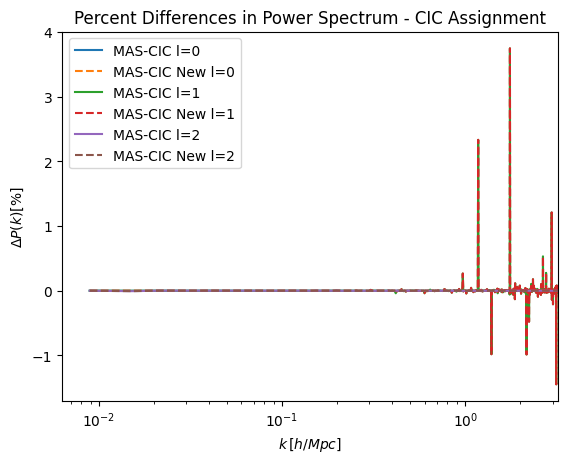

In [31]:
for l in [0,1,2]:
    plt.plot(pk_pylians.k3D[kselection], ((pk_cic_pyrecon.Pk[:,l]-pk_pylians.Pk[:,l])/(pk_pylians.Pk[:,l])*100)[kselection], label=f'MAS-CIC l={l}', linestyle='solid')
    plt.plot(pk_pylians.k3D[kselection], ((pk_cic_new.Pk[:,l]-pk_pylians.Pk[:,l])/(pk_pylians.Pk[:,l])*100)[kselection], label=f'MAS-CIC New l={l}', linestyle='dashed')
plt.xscale('log')
plt.yscale('linear')
plt.legend()
plt.ylabel('$\Delta P(k) [\%]$')
plt.xlabel('$k\, [h/Mpc]$')
plt.xlim(kmin, kmax)
plt.title('Percent Differences in Power Spectrum - CIC Assignment')

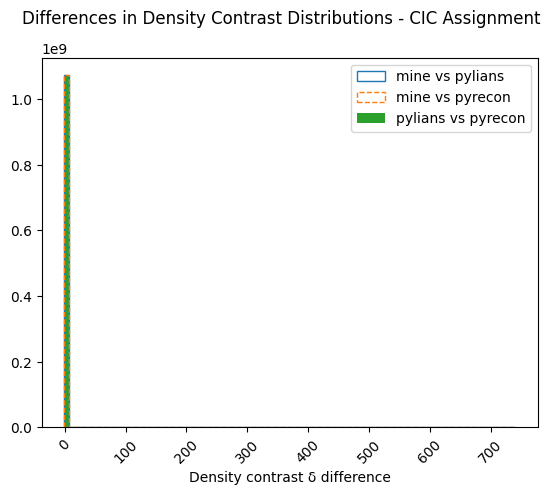

In [32]:
min_val = np.min([cic_delta_pylians.min(), cic_delta_new.min(), cic_delta_pyrecon.min()])
max_val = np.max([cic_delta_pylians.max(), cic_delta_new.max(), cic_delta_pyrecon.max()])

plt.hist(cic_delta_pylians.flatten()-cic_delta_new.flatten(), range=(min_val, max_val), bins=100, alpha=1, label='mine vs pylians', histtype='step')
plt.hist(cic_delta_pyrecon.flatten()-cic_delta_new.flatten(), range=(min_val, max_val), bins=100, alpha=1, label='mine vs pyrecon', histtype='step', linestyle='dashed')
plt.hist(cic_delta_pylians.flatten()-cic_delta_pyrecon.flatten(), range=(min_val, max_val), bins=100, alpha=1, label='pylians vs pyrecon', linestyle='dotted')
plt.xticks(rotation=45)
plt.suptitle('Differences in Density Contrast Distributions - CIC Assignment')
plt.xlabel('Density contrast δ difference')
plt.legend()

# Test NGP

## pylians NGP

In [33]:
# density field parameters
grid    = nmesh    #the 3D field will have grid x grid x grid voxels
BoxSize = 1000.0 #Mpc/h ; size of box
MAS     = 'NGP'  #mass-assigment scheme
verbose = True   #print information on progress

# define 3D density field
delta_NGP = np.zeros((grid,grid,grid), dtype=np.float32)

# construct 3D density field
MASL.MA(pos_h, delta_NGP, BoxSize, MAS, W=mass, verbose=verbose)

# at this point, delta contains the effective number of particles in each voxel
# now compute overdensity and density constrast
delta_NGP /= np.mean(delta_NGP, dtype=np.float32);  delta_NGP -= 1.0


Using NGP mass assignment scheme
Time taken = 1.945 seconds



## zeldareco NGP

In [34]:
rho_NGP_new = ma.ngp_ma(pos_h, BoxSize, nmesh, mass, verbose=True)

2026-05-13 13:05:01,062 - zeldareco.mass_assignment - INFO - Starting NGP mass assignment...
2026-05-13 13:05:01,065 - zeldareco.mass_assignment - INFO - weights not provided. Assuming all particles have unit mass.
2026-05-13 13:05:03,708 - zeldareco.mass_assignment - INFO - NGP mass assignment completed in 2.645496 seconds.


## pyrecon NGP

In [35]:
mesh = ParticleMesh(BoxSize=BoxSize, Nmesh=grid_shape, resampler='nnb')
pyrecon_rho_ngp = mesh.paint(pos_h, resampler='nnb')


## compare NGPs

In [36]:
#compute deltas from rhos
delta_NGP_new = rho_NGP_new / np.mean(rho_NGP_new, dtype=np.float64) - 1.0
delta_ngp_pyrecon = pyrecon_rho_ngp.value / pyrecon_rho_ngp.value.mean() - 1.0

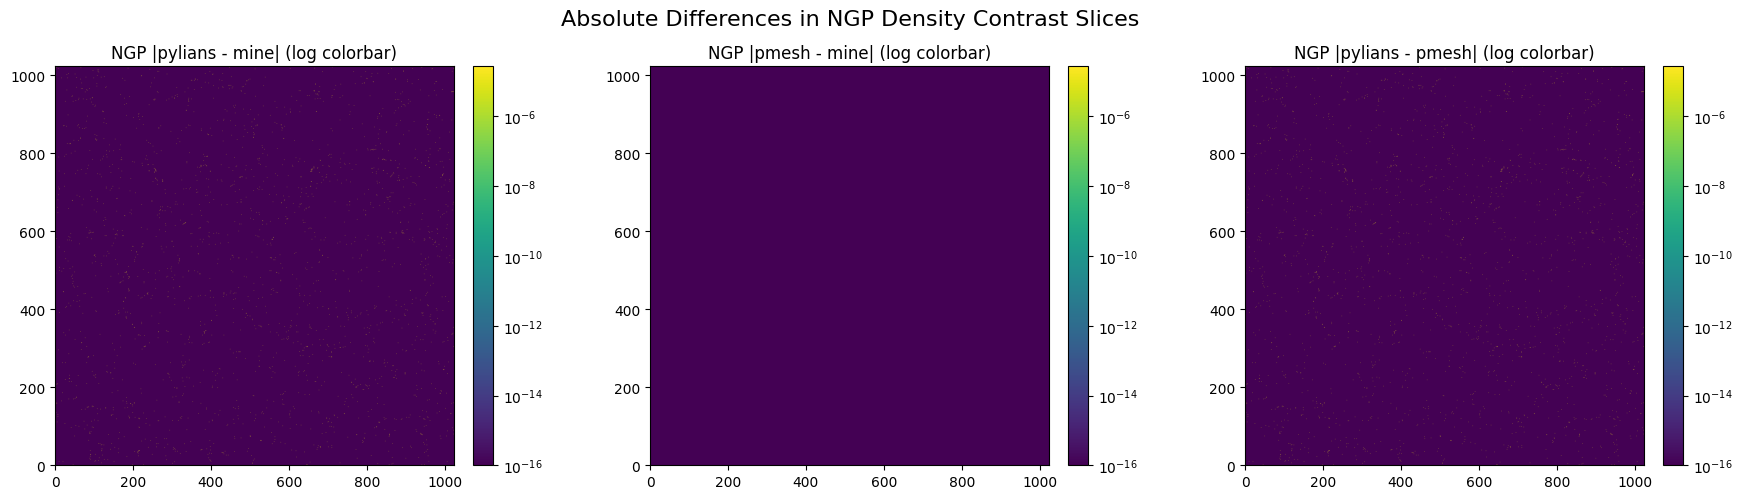

In [37]:
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# use absolute differences (log scale needs positive values) and add small epsilon
eps = 1e-16
diff0 = np.abs(delta_NGP[:, :, slab] - delta_NGP_new[:, :, slab]) + eps
diff1 = np.abs(delta_ngp_pyrecon[:, :, slab] - delta_NGP_new[:, :, slab]) + eps
diff3 = np.abs(delta_NGP[:, :, slab] - delta_ngp_pyrecon[:, :, slab]) + eps

# set common vmin/vmax for comparable colorbars, ensure vmin>0 for LogNorm
vmin = max(eps, min(diff0.min(), diff1.min(), diff3.min()))
vmax = max(diff0.max(), diff1.max(), diff3.max())
norm = LogNorm(vmin=vmin, vmax=vmax)

im0 = axes[0].imshow(diff0, norm=norm, origin='lower', cmap='viridis')
axes[0].set_title('NGP |pylians - mine| (log colorbar)')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(diff1, norm=norm, origin='lower', cmap='viridis')
axes[1].set_title('NGP |pmesh - mine| (log colorbar)')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(diff3, norm=norm, origin='lower', cmap='viridis')
axes[2].set_title('NGP |pylians - pmesh| (log colorbar)')
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle('Absolute Differences in NGP Density Contrast Slices', fontsize=16)


plt.tight_layout()
plt.show()

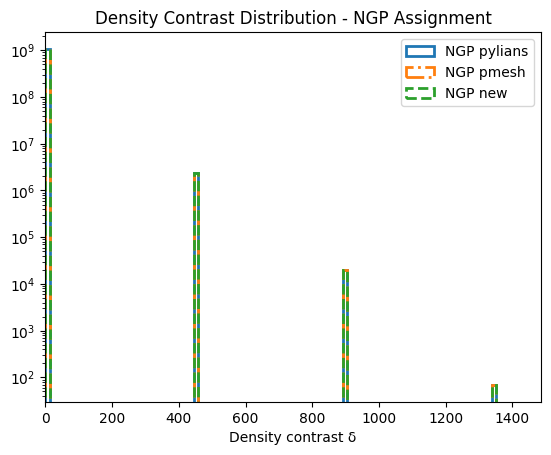

In [38]:
min_val = np.min([delta_NGP.min(), delta_NGP_new.min(), delta_ngp_pyrecon.min()])
max_val = np.max([delta_NGP.max(), delta_NGP_new.max(), delta_ngp_pyrecon.max()])

plt.hist(delta_NGP.flatten(), range=(min_val, max_val), bins=100, alpha=1, label='NGP pylians', histtype='step', linewidth=2)
plt.hist(delta_ngp_pyrecon.flatten(), range=(min_val, max_val), bins=100, alpha=1, label='NGP pmesh', histtype='step', linestyle='-.', linewidth=2)
plt.hist(delta_NGP_new.flatten(), range=(min_val, max_val), bins=100, alpha=1, label='NGP new', histtype='step', linestyle='--', linewidth=2)

plt.xlim(-1, 1.1*max_val)
plt.xscale('linear')
plt.yscale('log')
plt.xlabel('Density contrast δ')
plt.title('Density Contrast Distribution - NGP Assignment')
plt.legend()

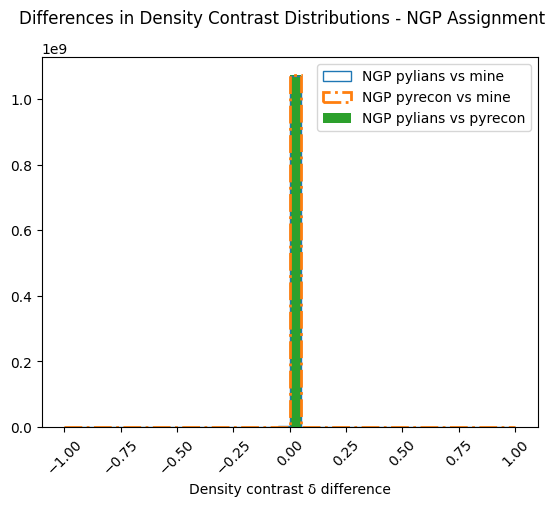

In [39]:
min_val =-1
max_val = 1


plt.hist(delta_NGP.flatten()-delta_NGP_new.flatten(), range=(min_val, max_val), bins=40, alpha=1, label='NGP pylians vs mine', histtype='step')
plt.hist(delta_ngp_pyrecon.flatten()-delta_NGP_new.flatten(), range=(min_val, max_val), bins=40, alpha=1, label='NGP pyrecon vs mine', histtype='step', linestyle='-.', linewidth=2)
plt.hist(delta_ngp_pyrecon.flatten()-delta_NGP.flatten(), range=(min_val, max_val), bins=40, alpha=1, label='NGP pylians vs pyrecon', linestyle=':', linewidth=2)

plt.xticks(rotation=45)
plt.xscale('linear')
plt.suptitle('Differences in Density Contrast Distributions - NGP Assignment')
plt.xlabel('Density contrast δ difference')
plt.legend()

In [40]:
## measure power spectra

pk_ngp_pylians = PKL.Pk(delta_NGP.astype(np.float32), BoxSize, axis=0, MAS=MAS, threads=1)
pk_ngp_pyrecon = PKL.Pk(delta_ngp_pyrecon.astype(np.float32), BoxSize, axis=0, MAS=MAS, threads=1)
pk_ngp_new = PKL.Pk(delta_NGP_new.astype(np.float32), BoxSize, axis=0, MAS=MAS, threads=1)



Computing power spectrum of the field...
Time to complete loop = 36.18
Time taken = 72.23 seconds

Computing power spectrum of the field...
Time to complete loop = 36.22
Time taken = 59.28 seconds

Computing power spectrum of the field...
Time to complete loop = 36.19
Time taken = 59.29 seconds


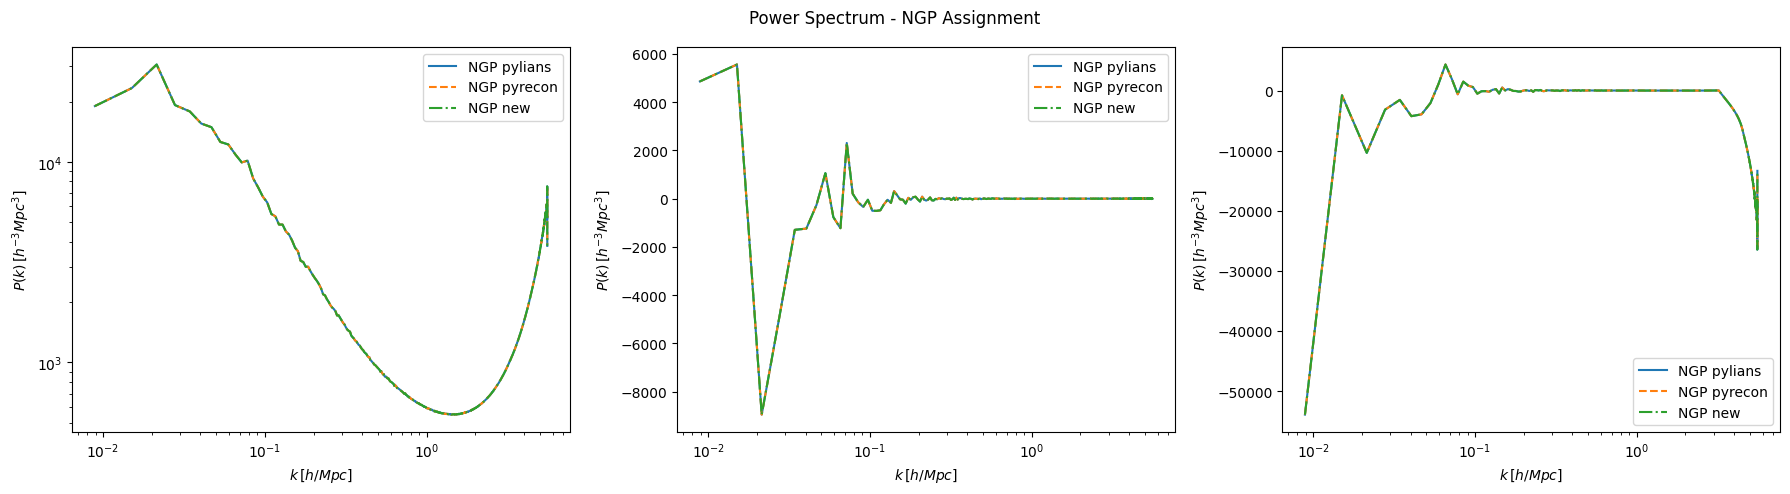

In [41]:
#plot pks
fig, axs = plt.subplots(1,3, figsize=(18, 5))

for i, ax in enumerate(axs):
    ax.plot(pk_ngp_pylians.k3D, pk_ngp_pylians.Pk[:,i], label='NGP pylians', linestyle='solid')
    ax.plot(pk_ngp_pyrecon.k3D, pk_ngp_pyrecon.Pk[:,i], label='NGP pyrecon', linestyle='dashed')
    ax.plot(pk_ngp_new.k3D, pk_ngp_new.Pk[:,i], label='NGP new', linestyle='dashdot')
    ax.legend()
    ax.set_xscale('log')
    ax.set_yscale('log') if i==0 else ax.set_yscale('linear')
    ax.set_xlabel('$k\, [h/Mpc]$')
    ax.set_ylabel('$P(k)\, [h^{-3}Mpc^{3}]$')
fig.suptitle('Power Spectrum - NGP Assignment')

plt.tight_layout()

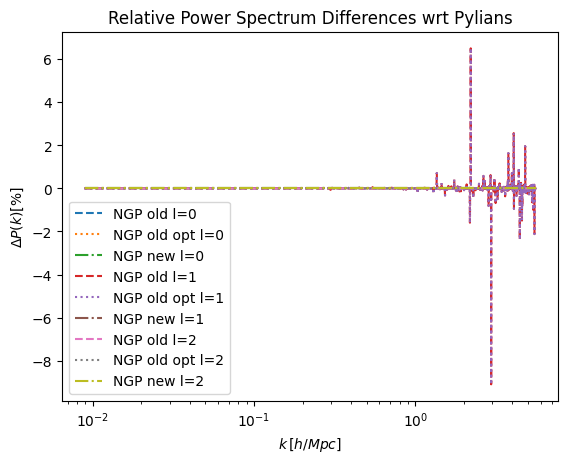

In [42]:
#plot pks

for l in [0,1,2]:
    plt.plot(pk_ngp_pyrecon.k3D, (pk_ngp_pyrecon.Pk[:,l]-pk_ngp_pylians.Pk[:,l])/(pk_ngp_pylians.Pk[:,l]), label=f'NGP old l={l}', linestyle='dashed')
    plt.plot(pk_ngp_pyrecon.k3D, (pk_ngp_pyrecon.Pk[:,l]-pk_ngp_pylians.Pk[:,l])/(pk_ngp_pylians.Pk[:,l]), label=f'NGP old opt l={l}', linestyle='dotted')
    plt.plot(pk_ngp_new.k3D, (pk_ngp_new.Pk[:,l]-pk_ngp_pylians.Pk[:,l])/(pk_ngp_pylians.Pk[:,l]), label=f'NGP new l={l}', linestyle='dashdot')

plt.xscale('log')
plt.yscale('linear')
plt.xlabel('$k\, [h/Mpc]$')
plt.ylabel('$\Delta P(k) [\%]$')
plt.title('Relative Power Spectrum Differences wrt Pylians')
plt.legend()

# Test TSC

## pylians TSC

In [43]:
# density field parameters
grid    = nmesh    #the 3D field will have grid x grid x grid voxels
BoxSize = 1000.0 #Mpc/h ; size of box
MAS     = 'TSC'  #mass-assigment scheme
verbose = True   #print information on progress

# define 3D density field
rho_TSC_pylians = np.zeros((grid,grid,grid), dtype=np.float32)

# construct 3D density field
MASL.MA(pos_h, rho_TSC_pylians, BoxSize, MAS, W=mass, verbose=verbose)

# at this point, delta contains the effective number of particles in each voxel
# now compute overdensity and density constrast
delta_TSC_pylians = rho_TSC_pylians/np.mean(rho_TSC_pylians, dtype=np.float32) - 1.0


Using TSC mass assignment scheme
Time taken = 2.527 seconds



## zeldareco TSC

In [44]:
from importlib import reload
reload(ma)

/conda/conda/emaragliano/envs/BAOrec/lib/python3.10/site-packages/numba/core/decorators.py:248: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


<module 'zeldareco.mass_assignment' from '/home/emaragliano/Work/Projects/Dottorato/ZeldovichReconstruction/zeldareco/mass_assignment.py'>

In [45]:
tsc_rho_new = ma.tsc_ma(pos_h, BoxSize, nmesh, mass, pbc=True, verbose=True, parallel=False)

2026-05-13 13:10:51,795 - zeldareco.mass_assignment - INFO - Using single-threaded TSC interpolation.



Starting TSC mass assignment...


2026-05-13 13:10:54,429 - zeldareco.mass_assignment - INFO - TSC mass assignment completed in 2.646111 seconds.


In [46]:
tsc_delta_new = tsc_rho_new / np.mean(tsc_rho_new, dtype=np.float64) - 1.0

## pyrecon TSC

In [47]:
mesh = ParticleMesh(BoxSize=BoxSize, Nmesh=grid_shape, resampler='tsc')
pyrecon_rho_tsc = mesh.paint(pos_h, resampler='tsc')

tsc_delta_pyrecon = pyrecon_rho_tsc.value / pyrecon_rho_tsc.value.mean() - 1.0

Text(0.5, 0, 'Density contrast δ')

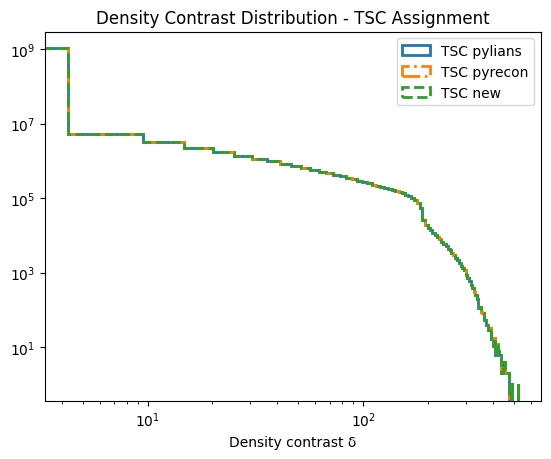

In [48]:
min_val = np.min([delta_TSC_pylians.min(), tsc_delta_new.min(), tsc_delta_pyrecon.min()])
max_val = np.max([delta_TSC_pylians.max(), tsc_delta_new.max(), tsc_delta_pyrecon.max()])

plt.hist(delta_TSC_pylians.flatten(), range=(min_val, max_val), bins=100, alpha=1, label='TSC pylians', histtype='step', linewidth=2)
plt.hist(tsc_delta_pyrecon.flatten(), range=(min_val, max_val), bins=100, alpha=1, label='TSC pyrecon', histtype='step', linestyle='-.', linewidth=2)
plt.hist(tsc_delta_new.flatten(), range=(min_val, max_val), bins=100, alpha=1, label='TSC new', histtype='step', linestyle='--', linewidth=2)

plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.title('Density Contrast Distribution - TSC Assignment')
plt.xlabel('Density contrast δ')

Text(0.5, 0.98, 'Differences in Density Contrast Distributions - TSC Assignment')

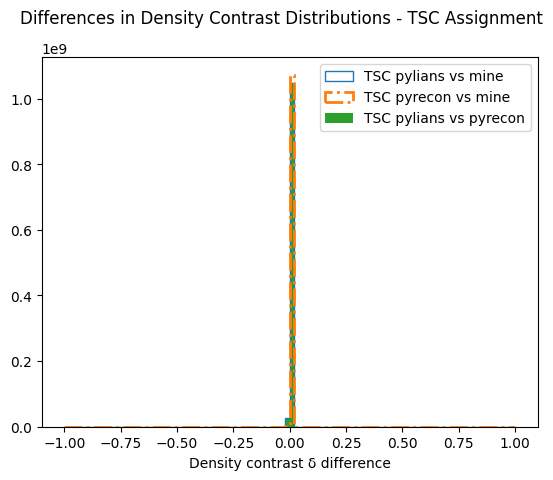

In [49]:
min_val = -1
max_val = 1


plt.hist(delta_TSC_pylians.flatten()-tsc_delta_new.flatten(), range=(min_val, max_val), bins=100, alpha=1, label='TSC pylians vs mine', histtype='step')
plt.hist(tsc_delta_pyrecon.flatten()-tsc_delta_new.flatten(), range=(min_val, max_val), bins=100, alpha=1, label='TSC pyrecon vs mine', histtype='step', linestyle='-.', linewidth=2)
plt.hist(tsc_delta_pyrecon.flatten()-delta_TSC_pylians.flatten(), range=(min_val, max_val), bins=100, alpha=1, label='TSC pylians vs pyrecon', linestyle=':', linewidth=2)
plt.legend()
plt.xscale('linear')
plt.xlabel('Density contrast δ difference')
plt.suptitle('Differences in Density Contrast Distributions - TSC Assignment')

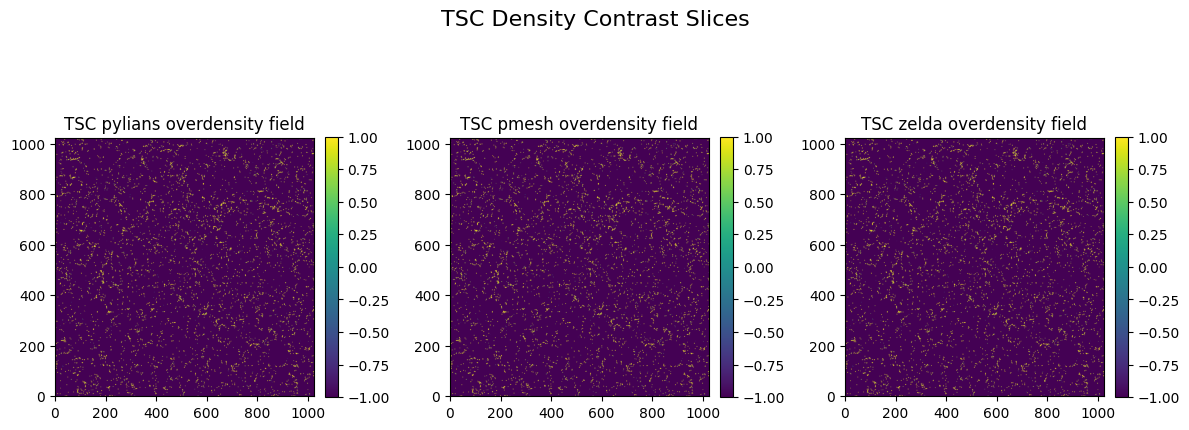

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

slab = 40

im0 = axes[0].imshow(delta_TSC_pylians[:, :, slab],
                     vmin=-1, vmax=1, origin='lower', cmap='viridis')
axes[0].set_title('TSC pylians overdensity field')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(tsc_delta_pyrecon[:, :, slab],
                     vmin=-1, vmax=1, origin='lower', cmap='viridis')
axes[1].set_title('TSC pmesh overdensity field')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(tsc_delta_new[:, :, slab],
                        vmin=-1, vmax=1, origin='lower', cmap='viridis')
axes[2].set_title('TSC zelda overdensity field')
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle('TSC Density Contrast Slices', fontsize=16)
plt.tight_layout()
plt.show()

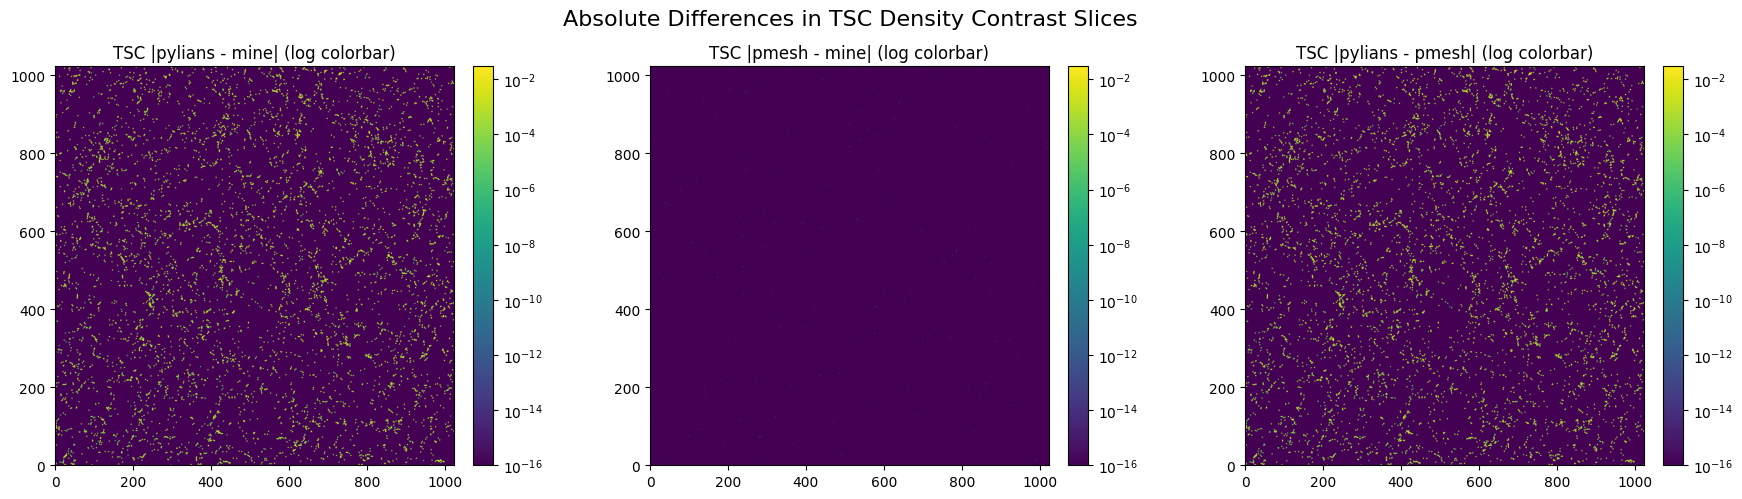

In [51]:
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

slab = 0

# use absolute differences (log scale needs positive values) and add small epsilon
eps = 1e-16
diff0 = np.abs(delta_TSC_pylians[:, :, slab] - tsc_delta_new[:, :, slab]) + eps
diff1 = np.abs(tsc_delta_pyrecon[:, :, slab] - tsc_delta_new[:, :, slab]) + eps
diff2 = np.abs(delta_TSC_pylians[:, :, slab] - tsc_delta_pyrecon[:, :, slab]) + eps

# set common vmin/vmax for comparable colorbars, ensure vmin>0 for LogNorm
vmin = max(eps, min(diff0.min(), diff1.min()), diff2.min())
vmax = max(diff0.max(), diff1.max(), diff2.max())
norm = LogNorm(vmin=vmin, vmax=vmax)

im0 = axes[0].imshow(diff0, norm=norm, origin='lower', cmap='viridis')
axes[0].set_title('TSC |pylians - mine| (log colorbar)')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(diff1, norm=norm, origin='lower', cmap='viridis')
axes[1].set_title('TSC |pmesh - mine| (log colorbar)')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(diff2, norm=norm, origin='lower', cmap='viridis')
axes[2].set_title('TSC |pylians - pmesh| (log colorbar)')
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
plt.suptitle('Absolute Differences in TSC Density Contrast Slices', fontsize=16)

plt.tight_layout()
plt.show()

In [52]:
#measure pks
pk_tsc_pylians = PKL.Pk(delta_TSC_pylians.astype(np.float32), BoxSize, axis=0, MAS=MAS, threads=1)
pk_tsc_pyrecon = PKL.Pk(tsc_delta_pyrecon.astype(np.float32), BoxSize, axis=0, MAS=MAS, threads=1)
pk_tsc_new = PKL.Pk(tsc_delta_new.astype(np.float32), BoxSize, axis=0, MAS=MAS, threads=1)


Computing power spectrum of the field...
Time to complete loop = 36.35
Time taken = 58.63 seconds

Computing power spectrum of the field...
Time to complete loop = 36.26
Time taken = 58.55 seconds

Computing power spectrum of the field...
Time to complete loop = 36.31
Time taken = 58.80 seconds


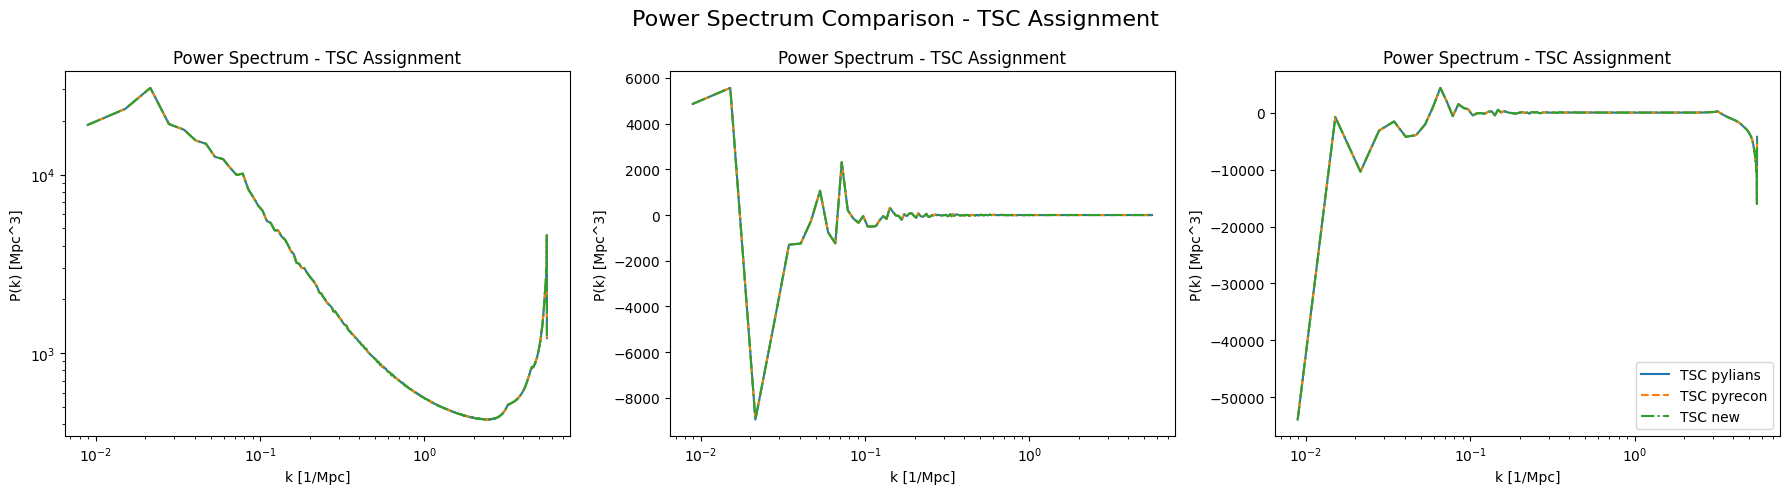

In [53]:
fig, axs = plt.subplots(1,3, figsize=(18, 5))

for i, ax in enumerate(axs):
    ax.plot(pk_tsc_pylians.k3D, pk_tsc_pylians.Pk[:,i], label='TSC pylians', linestyle='solid')
    ax.plot(pk_tsc_pyrecon.k3D, pk_tsc_pyrecon.Pk[:,i], label='TSC pyrecon', linestyle='dashed')
    ax.plot(pk_tsc_new.k3D, pk_tsc_new.Pk[:,i], label='TSC new', linestyle='dashdot')
    ax.set_xscale('log')
    ax.set_yscale('log') if i==0 else ax.set_yscale('linear')
    ax.set_title('Power Spectrum - TSC Assignment')
    ax.set_xlabel('k [1/Mpc]')
    ax.set_ylabel('P(k) [Mpc^3]')

plt.suptitle('Power Spectrum Comparison - TSC Assignment', fontsize=16)
plt.tight_layout()
plt.legend()

Text(0.5, 1.0, 'Percent Differences wrt Pylians')

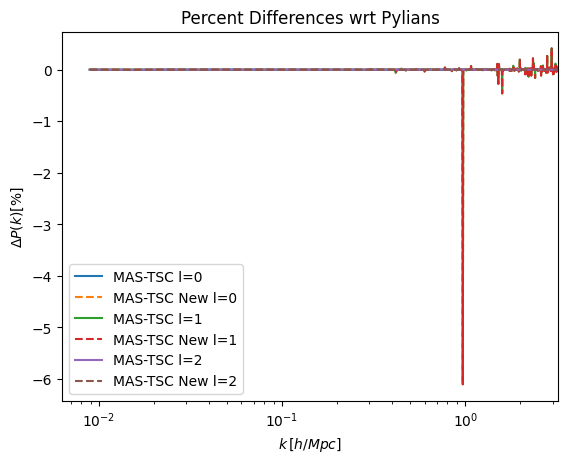

In [54]:
for l in [0,1,2]:
    plt.plot(pk_pylians.k3D[kselection], ((pk_tsc_pyrecon.Pk[:,l]-pk_tsc_pylians.Pk[:,l])/(pk_tsc_pylians.Pk[:,l])*100)[kselection], label=f'MAS-TSC l={l}', linestyle='solid')
    plt.plot(pk_pylians.k3D[kselection], ((pk_tsc_new.Pk[:,l]-pk_tsc_pylians.Pk[:,l])/(pk_tsc_pylians.Pk[:,l])*100)[kselection], label=f'MAS-TSC New l={l}', linestyle='dashed')
plt.xscale('log')
plt.yscale('linear')
plt.legend()
plt.ylabel('$\Delta P(k) [\%]$')
plt.xlabel('$k\, [h/Mpc]$')
plt.xlim(kmin, kmax)
plt.title('Percent Differences wrt Pylians')

In [55]:
for pk in [pk_tsc_pyrecon.Pk[:, 0], pk_tsc_new.Pk[:, 0]]:
    tolerance = 1e-4
    print(np.allclose(pk, pk_tsc_pylians.Pk[:, 0], rtol=tolerance))


False
False
